# Model 2: Tree-Based Comparison Models
**Zindi Urban Air Pollution Challenge — PM2.5 Prediction**

Loads the same combined feature table as `02_model_xgboost.ipynb` (`df_combined.parquet`), applies the same `sensor_altitude` exclusion (see `01_eda.ipynb` / `02_model_xgboost.ipynb` for the reasoning), and trains two comparison models on the team's shared, location-based `GroupKFold` validation strategy:
1. **Random Forest Regressor** (with imputation pipeline, hyperparameter search)
2. **HistGradientBoostingRegressor** with a log1p target transform (additional comparison)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

In [2]:
df_combined = pd.read_parquet("data/df_combined.parquet")
print(df_combined.shape)
df_combined.head()

(30557, 49)


,Place_ID,Date,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,...,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,wind_speed,wind_direction,wind_dir_sin,wind_dir_cos,split
0,010Q650,2020-01-02,-1.231330,0.006507,840209.874619,0.000057,6156.074219,0.000017,0.119095,234.151102,...,11.000000,60.200001,18.516840,1.996377,-1.227395,2.343506,328.416332,-0.523743,0.851876,train
1,010Q650,2020-01-03,-1.082553,0.018360,840772.941995,0.000055,6156.074219,0.000021,0.115179,233.313706,...,14.600000,48.799999,22.546533,3.330430,-1.188108,3.536009,340.366491,-0.336002,0.941861,train
2,010Q650,2020-01-04,-1.001242,0.015904,841410.713456,0.000059,7311.869141,0.000007,0.115876,232.233484,...,16.400000,33.400002,27.031030,5.065727,3.500559,6.157557,34.645557,0.568498,0.822685,train
3,010Q650,2020-01-05,-0.777019,0.055765,841103.242368,0.000060,11205.388333,0.000023,0.141557,230.936229,...,6.911948,21.300001,23.971857,3.004001,1.099468,3.198883,20.102680,0.343704,0.939078,train
4,010Q650,2020-01-06,0.366323,0.028530,840763.055499,0.000062,11205.372845,0.000009,0.126369,232.499132,...,13.900001,44.700001,16.816309,2.621787,2.670559,3.742413,45.527997,0.713593,0.700561,train


### Apply the Same Feature Exclusion as Model 1

`sensor_altitude` columns are dropped here too, for the same reason established in `02_model_xgboost.ipynb`: they reflect satellite orbital altitude, not a causal driver of PM2.5, and risk acting as a non-generalizable geographic proxy. **This must be applied identically across both model notebooks** so the RMSE comparison between models is on the same feature set, not an apples-to-oranges comparison.

In [3]:
drop_metadata = ['L3_AER_AI_sensor_altitude', 'L3_NO2_sensor_altitude', 'L3_CO_sensor_altitude']
df_combined = df_combined.drop(columns=drop_metadata)

In [4]:
train_mask = df_combined.split == 'train'
val_mask = df_combined.split == 'val'
assert set(df_combined.loc[train_mask, 'Place_ID']) & set(df_combined.loc[val_mask, 'Place_ID']) == set()

X_train = df_combined.loc[train_mask].drop(columns=['target', 'split', 'Place_ID', 'Date'])
y_train = df_combined.loc[train_mask, 'target']
groups_train = df_combined.loc[train_mask, 'Place_ID']

X_val = df_combined.loc[val_mask].drop(columns=['target', 'split', 'Place_ID', 'Date'])
y_val = df_combined.loc[val_mask, 'target']

X_train.shape

(24546, 42)

## Baseline Model — Dummy Regressor

In [5]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)  # features irrelevant - Dummy ignores X entirely
y_pred = dummy.predict(np.zeros((len(y_val), 1)))

baseline_rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 42.12


## Random Forest

### Pipeline

In [6]:
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),                 # RF can't handle NaNs natively
    ('rf',     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])
# Note: no scaler - tree models don't need feature scaling.

### Grid Search with GroupKFold

In [7]:
param_grid = {
    'rf__n_estimators':     [200, 400],
    'rf__max_depth':        [None, 15, 25],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features':     ['sqrt', 0.5],
}

cv = GroupKFold(n_splits=5)   # 5 folds, no Place_ID shared between folds

grid = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',   # RMSE (sklearn maximizes, so it's negated)
    n_jobs=-1,
    verbose=2,
)
grid.fit(X_train, y_train, groups=groups_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('impute',
                                        SimpleImputer(strategy='median')),
                                       ('rf',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 15, 25],
                         'rf__max_features': ['sqrt', 0.5],
                         'rf__min_samples_leaf': [1, 2, 5],
                         'rf__n_estimators': [200, 400]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [8]:
print('Best params:   ', grid.best_params_)
print('Best CV RMSE:  ', round(-grid.best_score_, 2))   # un-negate

Best params:    {'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 400}
Best CV RMSE:   35.23


In [9]:
pred = grid.predict(X_val)
val_rmse_all = np.sqrt(mean_squared_error(y_val, pred))
print(f'VAL RMSE: {val_rmse_all:.2f}')

VAL RMSE: 31.88


## Feature Importance & Feature Selection

Hyperparameter tuning is already done (`GridSearchCV` above) — this section inspects what the tuned model actually relies on, and checks whether a reduced feature set performs comparably (useful for interpretability and faster inference, not expected to beat the full feature set).

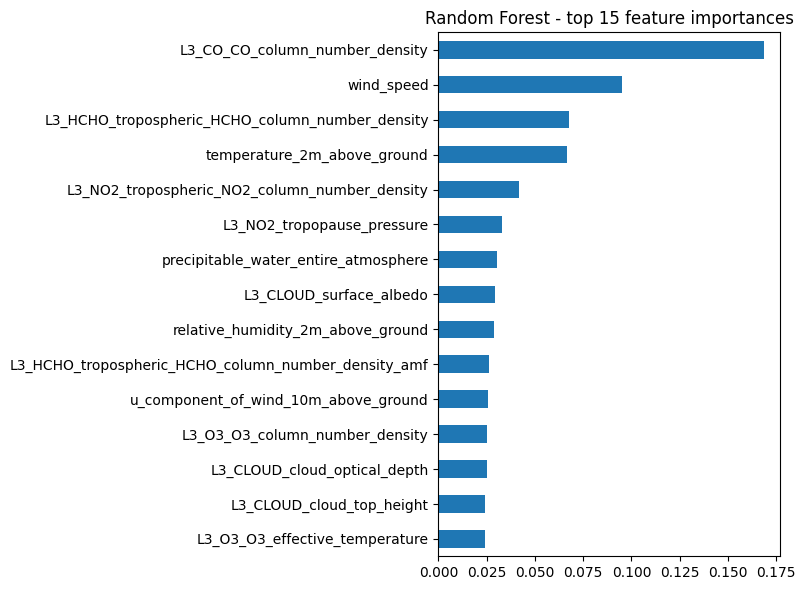

In [10]:
best_rf = grid.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importances.head(15).plot.barh(figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Random Forest - top 15 feature importances')
plt.tight_layout()
plt.show()

In [11]:
def run_with_top_n(n):
    cols  = importances.head(n).index.tolist()
    model = clone(grid.best_estimator_)          # same pipeline + best params
    model.fit(X_train[cols], y_train)
    pred  = model.predict(X_val[cols])
    rmse  = np.sqrt(mean_squared_error(y_val, pred))
    print(f'top {n:>2} features -> VAL RMSE = {rmse:.2f}')
    return rmse, cols

# Baseline: all features, for comparison (reusing the value computed above)
print(f'all {X_train.shape[1]} features -> VAL RMSE = {val_rmse_all:.2f}')

# Top 15 and top 25
rmse15, cols15 = run_with_top_n(15)
rmse25, cols25 = run_with_top_n(25)

all 42 features -> VAL RMSE = 31.88
top 15 features -> VAL RMSE = 32.39
top 25 features -> VAL RMSE = 31.93


## Gradient Boosting (Comparison Model)

An additional comparison model: `HistGradientBoostingRegressor`, which natively handles NaNs (no imputer needed), wrapped in a `TransformedTargetRegressor` with a `log1p` transform — PM2.5 concentration is right-skewed, and modeling `log(1 + target)` instead of the raw value tends to stabilize variance and reduce the influence of extreme outliers.

In [12]:
gb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)   # handles NaNs natively
gb_log = TransformedTargetRegressor(regressor=gb, func=np.log1p, inverse_func=np.expm1)

param_grid_gb = {
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth':     [None, 6, 10],
    'regressor__max_iter':      [300, 600],
}

cv = GroupKFold(n_splits=5)
grid_gb = GridSearchCV(gb_log, param_grid_gb, cv=cv,
                       scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid_gb.fit(X_train, y_train, groups=groups_train)

print('Best params:', grid_gb.best_params_)
print('Best CV RMSE:', round(-grid_gb.best_score_, 2))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 10, 'regressor__max_iter': 600}
Best CV RMSE: 35.85


In [13]:
def score(name, model):
    pred = np.clip(model.predict(X_val), 0, None)     # PM2.5 can't be negative
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae  = mean_absolute_error(y_val, pred)
    r2   = r2_score(y_val, pred)
    print(f'{name:22} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:6.3f}')
    return rmse

score('RandomForest (tuned)', grid)
score('HistGradientBoosting', grid_gb)

RandomForest (tuned)   RMSE= 31.88  MAE= 22.42  R2= 0.420
HistGradientBoosting   RMSE= 32.37  MAE= 21.27  R2= 0.403


32.3711306865744

## Summary

| Model | Setup | RMSE |
|---|---|---|
| Dummy (mean) | No features | *(fill in after running)* |
| Random Forest (tuned, `GridSearchCV`) | GroupKFold(5), held-out val | *(fill in after running)* |
| Random Forest, top-15 features | Same split | *(fill in after running)* |
| Random Forest, top-25 features | Same split | *(fill in after running)* |
| HistGradientBoosting (log1p target) | GroupKFold(5), held-out val | *(fill in after running)* |

All models use the same feature set as `02_model_xgboost.ipynb` (`sensor_altitude` columns excluded) for a fair comparison.

**Next:** see `README.md` for the full project summary and methodology writeup.